# FAIR-CARE: Survey Segments and WordCounts

In [1]:
import copy
import matplotlib.pyplot as plt

import os

import numpy as np
import pandas as pd

from slugify import slugify

# Get the root_path for this jupyter notebook repo.
repo_path = os.path.dirname(os.path.abspath(os.getcwd()))
# Use this path to save the wordcloud outputs
figs_path = os.path.join(
    repo_path, 'files', 'IMLS-FAIR-CARE-Survey', 'figs-select-word-counts',
)
rank_figs_path = os.path.join(
    repo_path, 'files', 'IMLS-FAIR-CARE-Survey', 'figs-ranks-select-options',
)
col_config_path = os.path.join(
    repo_path, 'files', 'IMLS-FAIR-CARE-Survey', 'imls-fair-care-survey-columns-config.csv',
)

processed_survey_path = '/home/ekansa/oc-data/fair-care-survey-processed.csv' # Keep this OUT of version control, has sensitive info
wide_survey_path = '/home/ekansa/oc-data/fair-care-survey-multi-select-expanded.csv' # Keep this OUT of version control, has sensitive info
semantic_clusters_path = '/home/ekansa/oc-data/fair-care-semantic-clusters-expanded.csv'

df_config = pd.read_csv(col_config_path, low_memory=False)
df = pd.read_csv(processed_survey_path, low_memory=False)
df_wide = pd.read_csv(wide_survey_path, low_memory=False)
df_semantic = pd.read_csv(semantic_clusters_path, low_memory=False)

print(f'FAIR+CARE survey has {len(df.index)} rows')
print(f'FAIR+CARE survey wide_survey data has {len(df_wide.index)} rows, {len(df_wide.columns)} columns')
print(f'FAIR+CARE survey semantic groupings has {len(df_semantic.index)} rows')

FAIR+CARE survey has 787 rows
FAIR+CARE survey wide_survey data has 787 rows, 271 columns
FAIR+CARE survey semantic groupings has 7242 rows


In [2]:
def get_original_column_metadata(column, df_config=df_config):
    """Gets the original column name from the df_config (column configuration data)"""
    config_index = (df_config['Working_Column_Name'] == column)
    if len(df_config[config_index].index) != 1:
        # We didn't find a matching column name
        return None
    row = df_config[config_index].iloc[0]
    keys = ['column', 'orig_column_index', 'Question Number', 'Section', 'Sub-Section', 'raw_column',]
    col_metadata = {k: row[k] for k in keys if k in df_config.columns.tolist()}
    return col_metadata


def get_select_option_value_from_tf_col(tf_col):
    """Gets the select option value from a TF column"""
    col_split = tf_col.split('::')
    select_option_value = col_split[1] # The second element.
    return select_option_value


def insert_line_breaks(text, max_chars):
    """Insert line breaks for long text"""
    words = text.split()  # Split the text into words
    current_line = []
    result = []
    for word in words:
        # Check if adding the next word exceeds the max_chars limit
        if len(' '.join(current_line + [word])) > max_chars:
            # Join the current line and add it to the result list
            result.append(' '.join(current_line))
            # Start a new line with the current word
            current_line = [word]
        else:
            # Add the word to the current line
            current_line.append(word)
    # Add the last line to the result list
    if current_line:
        result.append(' '.join(current_line))
    # Join all lines with a newline character
    return '\n'.join(result)


def round_up_to_base_int(x, base=50):
    rounded = x + (-x % base)
    if rounded < base:
        rounded = base
    return int(rounded)



def create_histogram_chart(
    word_counts,
    word_count_labels,
    title,
    caption,
    max_word_count,
    density=False,
    file_suffix='',
    save_dir=figs_path,
):
    """Make a histogram plot of word counts in the responses"""
    plt.style.use('seaborn-v0_8')
    num_bins = max_word_count / 5
    num_bins = int(round(num_bins, 0))
    if num_bins > 15:
        num_bins = 15
    bins = np.linspace(0, round_up_to_base_int(max_word_count), num_bins)
    if density:
        plt.hist(word_counts, bins, label=word_count_labels, density=True, )
        plt.ylabel('Normalized Density', fontsize=9)
    else:
        plt.ylabel('Count Responses', fontsize=9)
        plt.hist(word_counts, bins, label=word_count_labels, )
    plt.legend(loc='upper right')
    plt.title(title)
    xlabel = f'Response Word Counts\n{caption}'
    plt.xlabel(xlabel, fontsize=9)
    plt.tight_layout()
    plt.autoscale()
    slug_file = slugify(f'histo-{title}')
    filename = f'{slug_file}{file_suffix}.png'
    f_path = os.path.join(save_dir, filename)
    plt.savefig(f_path, bbox_inches='tight', dpi=150)
    plt.close()
    print(f'Saved figure: {filename}')


def make_filter_indices(df_wc):
    """Make lists of filter indices for charts"""
    crm_cols = [
        'Work: Work setting::CRM: Cultural Resources Consulting Firm::TF',
        'Work: Work setting::CRM: Tribally-Owned or similar Consulting Firm::TF',
        'Work: Work setting::CRM: Museum or University-based Consulting Organization::TF',
        'Work: Work setting::Construction Management Firm::TF',
        'Work: Work setting::CRM: Environmental or Engineering Consulting Firm::TF',
    ]

    # Make an index to select responses that indicate work in ANY CRM setting (lots of 'or' selections)
    any_crm_index = (df_wc[crm_cols[0]] == True)
    for crm_col in crm_cols[1:]:
        # Add an "or" option for the next CRM column
        any_crm_index |= (df_wc[crm_col] == True)
    
    
    work_group_configs = [
        ((df_wc['Work: Work setting::Academic: University or College::TF'] == True), '\nAcademic (Univ)', '-academic',),
        ((df_wc['Work: Work setting::Academic: University or College::TF'] == False), '\nNot Academic (Univ)', '-not-academic',),
        (any_crm_index, '\nCRM', '-crm',),
    ]
    
    region_configs = [
        ((df_wc['Region Focus: Work/research Region::North America (specify region)::TF'] == True), '\nN. America Focus', '-n-america',),
        ((df_wc['Region Focus: Work/research Region::North America (specify region)::TF'] == False), '\nOutside N. America Focus', '-out-n-america',),
    ]
    
    org_configs = [
        ((df_wc['Response Type: Individual or Org '] == 'Individual'), '\nResponding as Individual', '-resp-ind',),
        ((df_wc['Response Type: Individual or Org '].str.contains('Organization')), '\nResponding as Organization', '-resp-org',),
    ]
    
    filtered_plot_configs = [
        # (filter_index, title_suffix, file_suffix,),
        ((~df_wc['Response ID'].isnull()), '\nAll Reponses (Unfiltered)', '-all',),
    ] + work_group_configs + region_configs + org_configs

    return work_group_configs, region_configs, org_configs, filtered_plot_configs



In [3]:
# Columns used to identify responses from CRM settings
crm_cols = [
    'Work: Work setting::CRM: Cultural Resources Consulting Firm::TF',
    'Work: Work setting::CRM: Tribally-Owned or similar Consulting Firm::TF',
    'Work: Work setting::CRM: Museum or University-based Consulting Organization::TF',
    'Work: Work setting::Construction Management Firm::TF',
    'Work: Work setting::CRM: Environmental or Engineering Consulting Firm::TF',
]

wide_cols = [
    'Response ID', 
    'Demo: Age Range',	
    'Demo: Gender', 
    'Work: Work setting::Academic: University or College::TF',
    'Region Focus: Work/research Region::North America (specify region)::TF',
    'Response Type: Individual or Org ',
] + crm_cols

# Merge certain columns from the df_wide into the df_token dataset so we can
# filter by criteria from the df_wide.
sem_cols = [
    'Response ID',
    'column',
    'orig_column_index',
    'Question Number',
    'Important for Analysis',
    'Section',
    'Sub-Section',
    'response',
    'word_count',
]
df_semantic_grp = df_semantic[sem_cols].groupby(
    ['Response ID', 'column', 'orig_column_index',], 
    as_index=False
).agg(
    {
        'Question Number': 'first',
        'Important for Analysis': 'first',
        'Section': 'first',
        'Sub-Section': 'first',
        'response': 'first',
        'word_count': 'first',
    }
)

# Merge certain columns from the df_wide into the df_token dataset so we can
# filter by criteria from the df_wide.
df_wc = pd.merge(df_wide[wide_cols], df_semantic_grp, how='outer', on=['Response ID'])



In [4]:
# Make the filter indices used for charting.
work_group_configs, region_configs, org_configs, filtered_plot_configs = make_filter_indices(df_wc)

compare_configs = [
    ('Academic, Non-Academic, CRM', '-work', work_group_configs,),
    ('N. America and Outside N. America Focus', '-regions', work_group_configs,),
    ('Individual and Organization Responses', '-ind-org', org_configs,),
]

# Make groups of different sections, sub-sections that we'd like to use for word counts.
use_index = df_wc['orig_column_index'] >= 38
df_sec_grp = df_wc[use_index][['Section', 'Sub-Section']].groupby(['Section', 'Sub-Section'], as_index=False).first()

In [5]:
chart_rows = []
for _, gr_row in df_sec_grp.iterrows():
    section = gr_row['Section']
    sub_section = gr_row['Sub-Section']
    section_index = (df_wc['Section'] == section) & (df_wc['Sub-Section'] == sub_section)
    mean_word_count = df_wc[section_index]['word_count'].mean()
    count_respondants = df_wc[section_index]['Response ID'].unique().size
    count_questions = df_wc[section_index]['column'].unique().size
    title = f'{section} -- {sub_section} Words Counts'
    caption = f'(From n = {count_respondants} individual respondants; {count_questions} freetext questions)'
    main_row = {
        'title': title,
        'caption': caption,
        'count_respondants': count_respondants,
        'count_questions': count_questions,
        'mean_word_count': mean_word_count,
    }
    for filter_index, title_suffix, file_suffix in filtered_plot_configs:
        act_filter = filter_index & section_index
        if len(df_wc[act_filter].index) < 1:
            # No need to make a wordcloud from empty data!
            continue
        segment = title_suffix.replace('\n', '')
        segment_size = df_wc[act_filter]['Response ID'].unique().size
        segment_group = f'{segment}\n(n = {segment_size} responses)'
        seg_mean_word_count = df_wc[act_filter]['word_count'].mean()
        row = copy.deepcopy(main_row)
        row['segment'] = segment_group
        row['segment_size'] = segment_size
        row['segment_mean_word_count'] = seg_mean_word_count
        chart_rows.append(row)

df_simple = pd.DataFrame(chart_rows)
df_simple.head(20)

,title,caption,count_respondants,count_questions,mean_word_count,segment,segment_size,segment_mean_word_count
0,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,All Reponses (Unfiltered)\n(n = 297 responses),297,12.050936
1,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,Academic (Univ)\n(n = 100 responses),100,11.042553
2,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,Not Academic (Univ)\n(n = 194 responses),194,12.642173
3,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,CRM\n(n = 73 responses),73,10.960870
4,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,N. America Focus\n(n = 211 responses),211,12.686610
5,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,Outside N. America Focus\n(n = 81 responses),81,10.439516
6,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,Responding as Individual\n(n = 182 responses),182,11.733333
7,CARE -- Authority to Control Words Counts,(From n = 297 individual respondants; 7 freete...,297,7,12.050936,Responding as Organization\n(n = 106 responses),106,13.149425
8,CARE -- Collective Benefit Words Counts,(From n = 206 individual respondants; 3 freete...,206,3,17.138614,All Reponses (Unfiltered)\n(n = 206 responses),206,17.138614
9,CARE -- Collective Benefit Words Counts,(From n = 206 individual respondants; 3 freete...,206,3,17.138614,Academic (Univ)\n(n = 61 responses),61,15.000000


In [6]:
for comp_title, _, seg_configs in compare_configs:
    for _, gr_row in df_sec_grp.iterrows():
        section = gr_row['Section']
        sub_section = gr_row['Sub-Section']
        section_index = (df_wc['Section'] == section) & (df_wc['Sub-Section'] == sub_section)
        mean_word_count = df_wc[section_index]['word_count'].mean()
        max_word_count = df_wc[section_index]['word_count'].max()
        count_respondants = df_wc[section_index]['Response ID'].unique().size
        count_questions = df_wc[section_index]['column'].unique().size
        word_counts = []
        word_count_labels = []
        all_segments_resp_counts = 0
        for filter_index, title_suffix, _ in seg_configs:
            act_filter = filter_index & section_index
            if len(df_wc[act_filter].index) < 1:
                # No need to make a wordcloud from empty data!
                continue
            segment = title_suffix.replace('\n', '')
            segment_size = df_wc[act_filter]['Response ID'].unique().size
            segment_group = f'{segment}\n(n = {segment_size} responses)'
            word_counts.append(df_wc[act_filter]['word_count'])
            word_count_labels.append(segment_group)
            all_segments_resp_counts += segment_size
        
        title = f'{section} -- {sub_section} Words Counts\n{comp_title}'
        caption = f'(From n = {all_segments_resp_counts} individual respondants; {count_questions} freetext questions)'
        create_histogram_chart(
            word_counts=word_counts,
            word_count_labels=word_count_labels,
            title=title,
            caption=caption,
            max_word_count=max_word_count,
            density=False,
        )
        if True:
            # skip this.
            create_histogram_chart(
                word_counts=word_counts,
                word_count_labels=word_count_labels,
                title=f'{title} [Normalized]',
                caption=caption,
                max_word_count=max_word_count,
                density=True,
            )

Saved figure: histo-care-authority-to-control-words-counts-academic-non-academic-crm.png
Saved figure: histo-care-authority-to-control-words-counts-academic-non-academic-crm-normalized.png
Saved figure: histo-care-collective-benefit-words-counts-academic-non-academic-crm.png
Saved figure: histo-care-collective-benefit-words-counts-academic-non-academic-crm-normalized.png
Saved figure: histo-care-ethics-words-counts-academic-non-academic-crm.png
Saved figure: histo-care-ethics-words-counts-academic-non-academic-crm-normalized.png
Saved figure: histo-care-general-words-counts-academic-non-academic-crm.png
Saved figure: histo-care-general-words-counts-academic-non-academic-crm-normalized.png
Saved figure: histo-care-responsibility-words-counts-academic-non-academic-crm.png
Saved figure: histo-care-responsibility-words-counts-academic-non-academic-crm-normalized.png
Saved figure: histo-demographics-data-role-words-counts-academic-non-academic-crm.png
Saved figure: histo-demographics-data-r

## Make Bar Charts for the Sorted "Ideal Data Access Reuse" Question

This question asked survey takers to sort the most important potential source of guidance to promote data access and reuse.

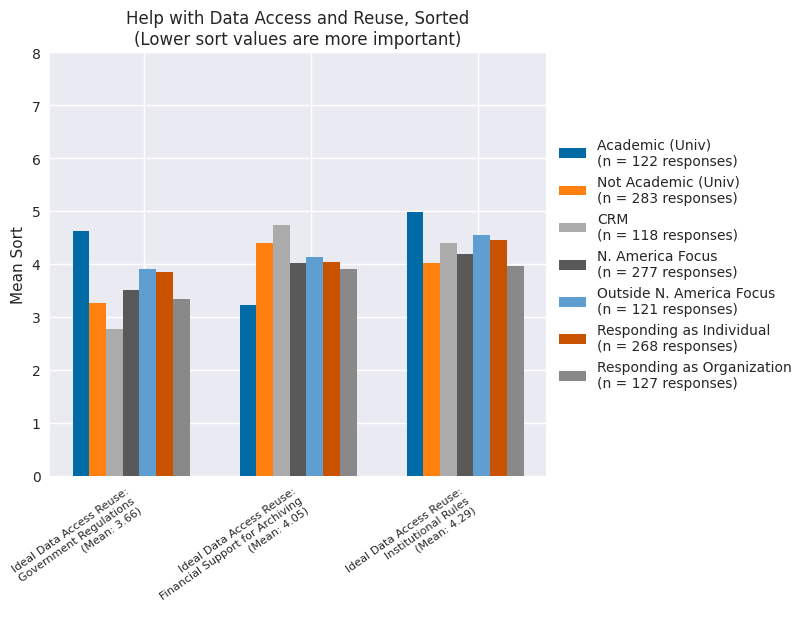

Saved figure: bar-help-with-data-access-reuse-sorting-1.png


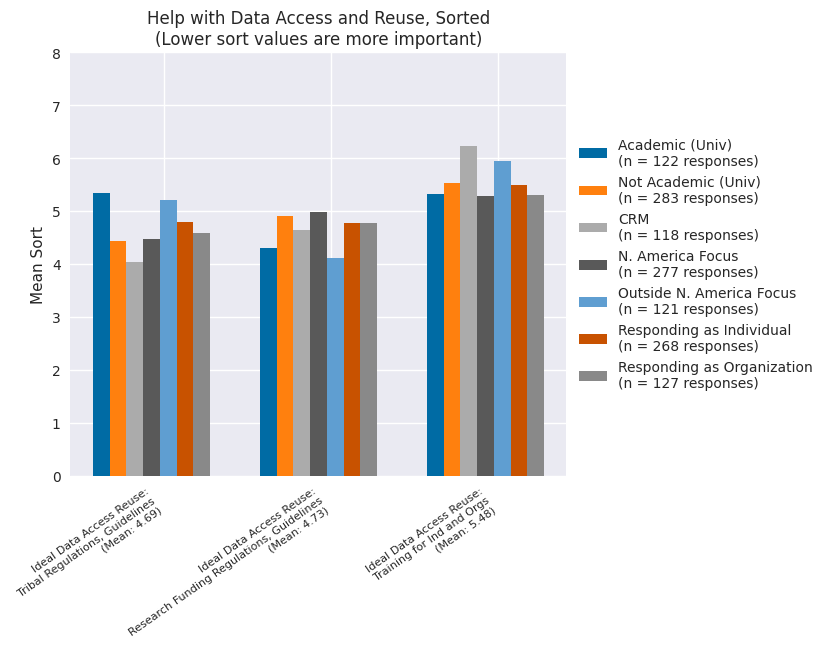

Saved figure: bar-help-with-data-access-reuse-sorting-2.png


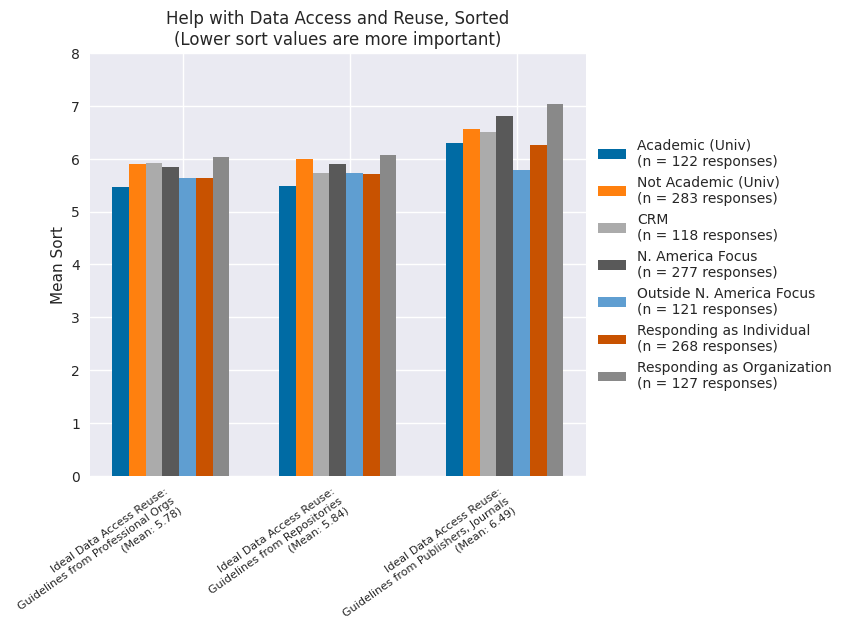

Saved figure: bar-help-with-data-access-reuse-sorting-3.png


In [37]:
def divide_chunks(l, n):
    # looping till length l
    for i in range(0, len(l), n): 
        yield l[i:i + n]

rank_cols = [
    'Ideal Data Access Reuse: Government Regulations',
    'Ideal Data Access Reuse: Tribal Regulations, Guidelines',
    'Ideal Data Access Reuse: Research Funding Regulations, Guidelines',
    'Ideal Data Access Reuse: Institutional Rules',
    'Ideal Data Access Reuse: Financial Support for Archiving',
    'Ideal Data Access Reuse: Guidelines from Publishers, Journals',
    'Ideal Data Access Reuse: Guidelines from Repositories',
    'Ideal Data Access Reuse: Guidelines from Professional Orgs',
    'Ideal Data Access Reuse: Training for Ind and Orgs',
]

_, _, _, filtered_bar_configs = make_filter_indices(df_wc=df_wide)
rank_cols_tups = []
max_rank = 0
for rank_col in rank_cols:
    col_index = ~df_wide[rank_col].isnull()
    col_mean_rank = df_wide[col_index][rank_col].mean()
    if max_rank < col_mean_rank:
        max_rank = round_up_to_base_int(col_mean_rank, base=8)
    rank_cols_tups.append((rank_col, col_mean_rank,))

# Sort the rank columns in order of their typical ranking
sorted_rank_cols = sorted(rank_cols_tups, key=lambda x: x[1], reverse=False)

chunk_rank_cols = divide_chunks(sorted_rank_cols, n=3)


# Make an index that selects members of a segment that have made any
# ranking in the rank_col columns.
segment_any_rank_col_index = {}
for filter_index, title_suffix, file_suffix in filtered_bar_configs:
    segment = title_suffix.replace('\n', '')
    rank_col_index = df_wide[rank_cols[0]] > 0
    for rank_col in rank_cols[1:]:
        rank_col_index |= df_wide[rank_col] > 0
    filter_index &= ~df_wide['Response ID'].isnull()
    segment_any_rank_col_index[segment] = filter_index & (rank_col_index)


chunk_num = 0
for act_chunk_rank_cols in chunk_rank_cols:
    chunk_num += 1
    rank_col_labels = []
    segment_means = {}
    for rank_col, mean_rank in act_chunk_rank_cols:
        rank_col_label = rank_col.replace(': ', ':\n')
        rank_col_label  = rank_col_label + f'\n(Mean: {round(mean_rank,2)})'
        rank_col_labels.append(rank_col_label)
        for filter_index, title_suffix, file_suffix in filtered_bar_configs:
            if file_suffix == '-all':
                # skip the all category
                continue
            act_index = (df_wide[rank_col] > 0) & filter_index
            segment = title_suffix.replace('\n', '')
            seg_size_index = segment_any_rank_col_index.get(segment)
            segment_size = len(df_wide[seg_size_index].index)
            segment_group = f'{segment}\n(n = {segment_size} responses)'
            segment_mean = df_wide[act_index][rank_col].mean()
            if not segment_means.get(segment_group):
                segment_means[segment_group] = []
            segment_means[segment_group].append(segment_mean)
    
    x = np.arange(len(rank_col_labels))  # the label locations
    width = 0.1  # the width of the bars
    multiplier = 0
    plt.style.use('tableau-colorblind10')
    fig, ax = plt.subplots(layout='constrained')
    for attribute, measurement in segment_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        # ax.bar_label(rects, padding=3)
        multiplier += 1
        
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Mean Sort')
    ax.set_title('Help with Data Access and Reuse, Sorted\n(Lower sort values are more important)')
    ax.set_xticks(x + (width + (width * 2.75)), rank_col_labels)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_ylim(0, max_rank)
    plt.xticks(rotation=35, ha='right', fontsize=8)
    plt.show()
    filename = f'bar-help-with-data-access-reuse-sorting-{chunk_num}.png'
    f_path = os.path.join(rank_figs_path, filename)
    fig.savefig(f_path, bbox_inches='tight', dpi=150)
    plt.close()
    print(f'Saved figure: {filename}')

segment: Academic (Univ) cat: Yes count 72 size 110 percent 0.65
segment: Academic (Univ) cat: Maybe, but I need more information count 33 size 110 percent 0.3
segment: Academic (Univ) cat: No count 5 size 110 percent 0.05
segment: Not Academic (Univ) cat: Yes count 100 size 241 percent 0.41
segment: Not Academic (Univ) cat: Maybe, but I need more information count 118 size 241 percent 0.49
segment: Not Academic (Univ) cat: No count 23 size 241 percent 0.1
segment: CRM cat: Yes count 36 size 95 percent 0.38
segment: CRM cat: Maybe, but I need more information count 50 size 95 percent 0.53
segment: CRM cat: No count 9 size 95 percent 0.09
segment: N. America Focus cat: Yes count 104 size 237 percent 0.44
segment: N. America Focus cat: Maybe, but I need more information count 119 size 237 percent 0.5
segment: N. America Focus cat: No count 14 size 237 percent 0.06
segment: Outside N. America Focus cat: Yes count 63 size 109 percent 0.58
segment: Outside N. America Focus cat: Maybe, but I

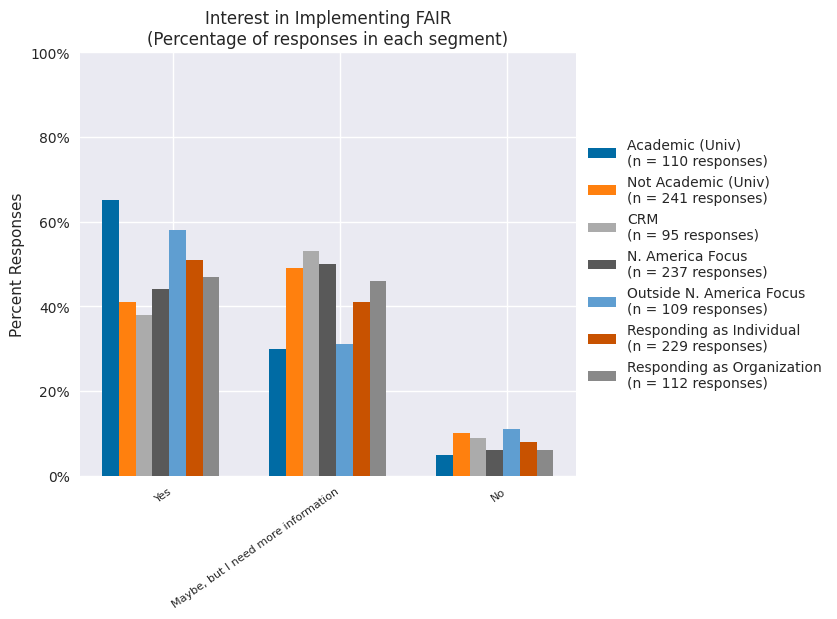

Saved figure: bar-interest-fair.png
segment: Academic (Univ) cat: Yes count 63 size 110 percent 0.57
segment: Academic (Univ) cat: Maybe, but I need more information count 39 size 110 percent 0.35
segment: Academic (Univ) cat: No count 8 size 110 percent 0.07
segment: Not Academic (Univ) cat: Yes count 95 size 242 percent 0.39
segment: Not Academic (Univ) cat: Maybe, but I need more information count 121 size 242 percent 0.5
segment: Not Academic (Univ) cat: No count 26 size 242 percent 0.11
segment: CRM cat: Yes count 40 size 95 percent 0.42
segment: CRM cat: Maybe, but I need more information count 47 size 95 percent 0.49
segment: CRM cat: No count 8 size 95 percent 0.08
segment: N. America Focus cat: Yes count 101 size 238 percent 0.42
segment: N. America Focus cat: Maybe, but I need more information count 119 size 238 percent 0.5
segment: N. America Focus cat: No count 18 size 238 percent 0.08
segment: Outside N. America Focus cat: Yes count 52 size 109 percent 0.48
segment: Outsid

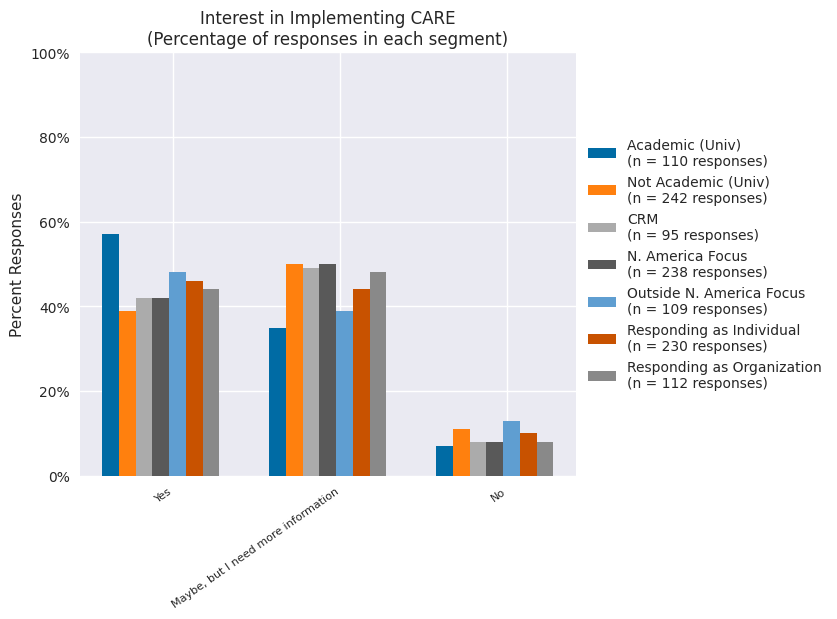

Saved figure: bar-interest-care.png


In [40]:
from matplotlib.ticker import FuncFormatter
cat_cols = [
    'Interest in Implementing FAIR',
    'Interest in Implementing CARE',
]
cat_vals = ['Yes', 'Maybe, but I need more information', 'No',]
for cat_col in cat_cols:
    cat_index = ~df_wide[cat_col].isnull() & (df_wide[cat_col].isin(cat_vals))
    segment_percents = {}
    max_seg_cat_percent = 0
    for filter_index, title_suffix, file_suffix in filtered_bar_configs:
        segment = title_suffix.replace('\n', '')
        seg_size_index = cat_index & filter_index
        segment_size = len(df_wide[seg_size_index].index)
        segment_group = f'{segment}\n(n = {segment_size} responses)'
        if file_suffix == '-all':
            # skip the all category
            continue
        for cat_val in cat_vals:  
            seg_cat_index = (df_wide[cat_col] == cat_val) & filter_index
            segment_cat_count = len(df_wide[seg_cat_index].index)
            percent_seg_count = round((segment_cat_count/segment_size), 2)
            print(f'segment: {segment} cat: {cat_val} count {segment_cat_count} size {segment_size} percent {percent_seg_count}')
            if max_seg_cat_percent < percent_seg_count:
                max_seg_cat_percent = percent_seg_count
            if not segment_percents.get(segment_group):
                segment_percents[segment_group] = []
            segment_percents[segment_group].append(percent_seg_count)

    x = np.arange(len(cat_vals))  # the label locations
    width = 0.1  # the width of the bars
    multiplier = 0
    plt.style.use('tableau-colorblind10')
    fig, ax = plt.subplots(layout='constrained')
    for attribute, measurement in segment_percents.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        # ax.bar_label(rects, padding=3)
        multiplier += 1
        
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Percent Responses')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
    ax.set_title(f'{cat_col}\n(Percentage of responses in each segment)')
    ax.set_xticks(x + (width + (width * 2.75)), cat_vals)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_ylim(0, 1)
    plt.xticks(rotation=35, ha='right', fontsize=8)
    plt.show()
    if 'FAIR' in cat_col:
        filename = f'bar-interest-fair.png'
    else:
        filename = f'bar-interest-care.png'
    f_path = os.path.join(rank_figs_path, filename)
    fig.savefig(f_path, bbox_inches='tight', dpi=150)
    plt.close()
    print(f'Saved figure: {filename}')